In [1]:
print("Real Estate Buyer Segmentation Project")

Real Estate Buyer Segmentation Project


# Machine Learning Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence

## Step 1 — Project Setup and Data Loading

In [2]:
import pandas as pd

In [3]:
c = pd.read_csv("../data/clients.csv")
c.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [4]:
p = pd.read_csv("../data/properties.csv")
p.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [5]:
print("Clients dataset:", c.shape)
print("Properties dataset:", p.shape)

Clients dataset: (2000, 12)
Properties dataset: (10000, 9)


#Step 2 -- Data Understanding

In [6]:
c.columns.tolist()

['client_id',
 'client_type',
 'first_name',
 'last_name',
 'date_of_birth',
 'gender',
 'country',
 'region',
 'acquisition_purpose',
 'satisfaction_score',
 'loan_applied',
 'referral_channel']

In [7]:
p.columns.tolist()

['listing_id',
 'tower_number',
 'transaction_date',
 'unit_category',
 'unit_number',
 'floor_area_sqft',
 'sale_price',
 'listing_status',
 'client_ref']

In [8]:
c.shape

(2000, 12)

In [9]:
p.shape

(10000, 9)

In [10]:
c.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   client_id            2000 non-null   str  
 1   client_type          2000 non-null   str  
 2   first_name           2000 non-null   str  
 3   last_name            2000 non-null   str  
 4   date_of_birth        2000 non-null   str  
 5   gender               2000 non-null   str  
 6   country              2000 non-null   str  
 7   region               2000 non-null   str  
 8   acquisition_purpose  2000 non-null   str  
 9   satisfaction_score   2000 non-null   int64
 10  loan_applied         2000 non-null   str  
 11  referral_channel     2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 187.6 KB


In [11]:
p.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  str    
 3   unit_category     10000 non-null  str    
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  str    
 7   listing_status    10000 non-null  str    
 8   client_ref        7305 non-null   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 703.3 KB


In [12]:
c.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [13]:
p.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [14]:
c.isnull().mean()*100

client_id              0.0
client_type            0.0
first_name             0.0
last_name              0.0
date_of_birth          0.0
gender                 0.0
country                0.0
region                 0.0
acquisition_purpose    0.0
satisfaction_score     0.0
loan_applied           0.0
referral_channel       0.0
dtype: float64

In [15]:
p.isnull().mean()*100

listing_id           0.00
tower_number         0.00
transaction_date     0.00
unit_category        0.00
unit_number          0.00
floor_area_sqft      0.00
sale_price           0.00
listing_status       0.00
client_ref          26.95
dtype: float64

In [16]:
c.duplicated().sum()

np.int64(0)

In [17]:
p.duplicated().sum()

np.int64(0)

In [18]:
c["client_id"].duplicated().sum()

np.int64(0)

In [19]:
c.describe()

,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [20]:
p.describe()

,listing_id,tower_number,unit_number,floor_area_sqft
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,105898.277400,10.370100,28.99920,1139.941412
std,74414.566199,5.769025,16.88242,418.373967
min,1002.000000,1.000000,1.00000,410.710000
25%,50389.750000,5.000000,15.00000,782.200000
50%,100404.500000,10.000000,29.00000,1110.880000
75%,150411.250000,15.000000,43.00000,1499.000000
max,990026.000000,20.000000,70.00000,1957.160000


In [21]:
c.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='str')

In [22]:
c['client_id'].duplicated().sum()*100

np.int64(0)

In [23]:
c['client_type'].unique()

<StringArray>
['Individual', 'Company']
Length: 2, dtype: str

In [24]:
c['loan_applied'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [25]:
c['referral_channel'].unique()

<StringArray>
['Website', 'Agency', 'Client']
Length: 3, dtype: str

In [26]:
c['satisfaction_score'].unique()

array([4, 1, 5, 3, 2])

In [27]:
p.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='str')

In [28]:
p['listing_id'].duplicated().sum()

np.int64(0)

In [29]:
p['tower_number'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [30]:
p['floor_area_sqft'].unique()

array([1160.36,  782.25,  756.21, ...,  736.63,  606.33, 1565.91],
      shape=(1208,))

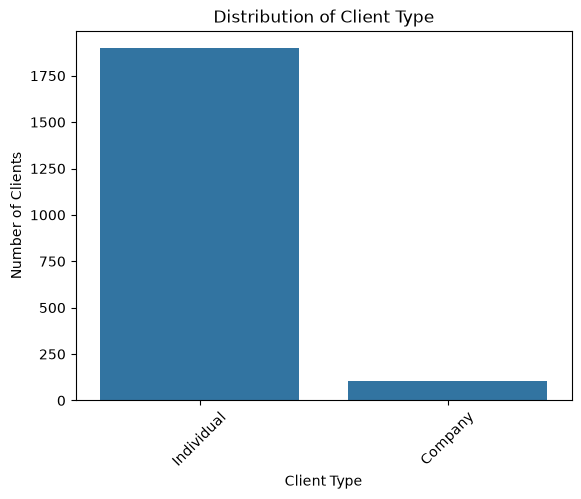

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=c, x="client_type")

plt.title("Distribution of Client Type")
plt.xlabel("Client Type")
plt.ylabel("Number of Clients")
plt.xticks(rotation=45)

plt.show()

#Step 3 -- Data Cleaning

In [32]:
c.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [33]:
p.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [34]:
c_clean = c.copy()

In [35]:
p_clean = p.copy()

In [36]:
print(c_clean.shape)
print(p_clean.shape)

(2000, 12)
(10000, 9)


In [37]:
c_clean.columns = (
    c_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

p_clean.columns = (
    p_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [38]:
c_clean.columns

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='str')

In [40]:
p_clean.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='str')

In [41]:
c_clean["client_type"] = c_clean["client_type"].replace({
    "Company": "Corporate"
})

In [42]:
c_clean["client_type"].value_counts()

client_type
Individual    1897
Corporate      103
Name: count, dtype: int64

In [43]:
categorical_cols = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

for col in categorical_cols:
    print("\n" + col)
    print(c_clean[col].value_counts())


client_type
client_type
Individual    1897
Corporate      103
Name: count, dtype: int64

gender
gender
M    1012
F     988
Name: count, dtype: int64

country
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

region
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Northern Ireland           24
Ohio                       24
British Columbia           20
Wales                      17
Hamburg                    16
Flanders    

In [44]:
for col in categorical_cols:
    c_clean[col] = c_clean[col].str.strip()

In [45]:
for col in categorical_cols:
    print("\n" + col)
    print(c_clean[col].unique())


client_type
<StringArray>
['Individual', 'Corporate']
Length: 2, dtype: str

gender
<StringArray>
['F', 'M']
Length: 2, dtype: str

country
<StringArray>
[      'USA',    'Canada',   'Germany',   'Belgium',    'Mexico',    'Russia',
        'UK',   'Denmark',    'France', 'Australia']
Length: 10, dtype: str

region
<StringArray>
[            'California',                 'Quebec',                 'Oregon',
                'Arizona',                 'Berlin',                 'Nevada',
               'Colorado',               'Brussels',            'Mexico City',
         'Krasnodar Krai',                   'Utah',       'Northern Ireland',
         'Capital Region',               'Virginia',                'Wyoming',
                 'Kansas',       'Saint Petersburg',               'Scotland',
            'Novosibirsk',                   'Ohio',             'Washington',
                'England',                  'Texas', 'North Rhine-Westphalia',
                'Florida',          

In [46]:
c_clean["date_of_birth"] = pd.to_datetime(
    c_clean["date_of_birth"],
    errors="coerce"
)

In [47]:
c_clean["date_of_birth"].dtype

dtype('<M8[us]')

In [ ]:
c_clean["date_of_birth"].isnull().sum()

np.int64(1145)

In [49]:
invalid_dob = c_clean[c_clean["date_of_birth"].isna()]

invalid_dob.head(20)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
1,C0002,Individual,Trystan,Oconnor,NaT,M,USA,California,Home,1,No,Website
3,C0004,Individual,Russell,Gross,NaT,M,USA,California,Home,5,No,Website
4,C0005,Corporate,Marleez,Co,NaT,M,USA,California,Investment,5,No,Website
6,C0007,Individual,Xavier,Faulkner,NaT,M,Canada,Quebec,Investment,5,No,Website
7,C0008,Individual,Kayden,Olsen,NaT,F,USA,California,Home,5,No,Website
9,C0010,Individual,Nicolas,Navarro,NaT,M,USA,Oregon,Investment,3,No,Agency
10,C0011,Individual,Laci,Guerra,NaT,F,USA,California,Home,2,Yes,Website
11,C0012,Corporate,Kylax,Co,NaT,M,USA,California,Investment,5,No,Website
14,C0015,Individual,Jaylynn,Hickman,NaT,F,USA,California,Home,5,No,Client
19,C0020,Individual,Camille,Sharp,NaT,F,USA,California,Home,5,No,Website


In [50]:
c.loc[c_clean["date_of_birth"].isna(), "date_of_birth"].head(20)

1     11/26/1962
3     11/25/1959
4      2/28/1976
6      5/24/1947
7     10/17/1969
9      6/17/1966
10     6/17/1956
11     4/25/1975
14     8/19/1941
19    10/17/1967
21     9/14/1966
24     1/20/1937
25     9/23/1962
27     4/15/1958
28     2/26/1976
29     6/19/1952
30    12/25/1977
32     8/14/1968
33    10/30/1969
36     1/20/1962
Name: date_of_birth, dtype: str

In [51]:
c["date_of_birth"].head(30).tolist()

['05-11-1968',
 '11/26/1962',
 '04-07-1959',
 '11/25/1959',
 '2/28/1976',
 '03-06-1957',
 '5/24/1947',
 '10/17/1969',
 '10-05-1975',
 '6/17/1966',
 '6/17/1956',
 '4/25/1975',
 '08-10-1962',
 '07-10-1980',
 '8/19/1941',
 '09-03-1939',
 '01-08-1977',
 '02-07-1967',
 '09-09-1957',
 '10/17/1967',
 '06-09-1938',
 '9/14/1966',
 '12-06-1958',
 '11-05-1963',
 '1/20/1937',
 '9/23/1962',
 '09-08-1968',
 '4/15/1958',
 '2/26/1976',
 '6/19/1952']

In [52]:
c["date_of_birth"].isnull().sum()

np.int64(0)

In [54]:
c_clean["date_of_birth"] = c["date_of_birth"].copy()

In [56]:
# Convert mixed date-of-birth formats and create age

dob_raw = c["date_of_birth"].astype("string").str.strip()

dob_parsed = pd.Series(
    pd.NaT,
    index=c_clean.index,
    dtype="datetime64[ns]"
)

# Format: MM/DD/YYYY
slash_mask = dob_raw.str.contains("/", na=False)
dob_parsed.loc[slash_mask] = pd.to_datetime(
    dob_raw.loc[slash_mask],
    format="%m/%d/%Y",
    errors="coerce"
)

# Format: DD-MM-YYYY
hyphen_mask = dob_raw.str.contains("-", na=False)
dob_parsed.loc[hyphen_mask] = pd.to_datetime(
    dob_raw.loc[hyphen_mask],
    format="%d-%m-%Y",
    errors="coerce"
)

# Store cleaned DOB
c_clean["date_of_birth"] = dob_parsed

# Create age
reference_date = pd.Timestamp("2026-09-22")

c_clean["age"] = (
    (reference_date - c_clean["date_of_birth"]).dt.days / 365.25
).round(0)

# Check results
print("Missing DOB:", c_clean["date_of_birth"].isnull().sum())
print("\nAge summary:")
print(c_clean["age"].describe())

print("\nSample:")
print(c_clean[["date_of_birth", "age"]].head(10))

Missing DOB: 0

Age summary:
count    2000.000000
mean       56.319500
std        17.355692
min        26.000000
25%        42.000000
50%        57.000000
75%        71.000000
max        96.000000
Name: age, dtype: float64

Sample:
  date_of_birth   age
0    1968-11-05  58.0
1    1962-11-26  64.0
2    1959-07-04  67.0
3    1959-11-25  67.0
4    1976-02-28  51.0
5    1957-06-03  69.0
6    1947-05-24  79.0
7    1969-10-17  57.0
8    1975-05-10  51.0
9    1966-06-17  60.0


In [57]:
# Clean sale_price and transaction_date

# Convert sale price from text such as "$300,385.62" to numeric
p_clean["sale_price"] = (
    p_clean["sale_price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

p_clean["sale_price"] = pd.to_numeric(
    p_clean["sale_price"],
    errors="coerce"
)

# Convert transaction date to datetime
p_clean["transaction_date"] = pd.to_datetime(
    p_clean["transaction_date"],
    errors="coerce"
)

# Check results
print("Sale price data type:", p_clean["sale_price"].dtype)
print("Missing sale prices:", p_clean["sale_price"].isnull().sum())

print("\nTransaction date data type:", p_clean["transaction_date"].dtype)
print("Missing transaction dates:", p_clean["transaction_date"].isnull().sum())

print("\nSale price summary:")
print(p_clean["sale_price"].describe())

print("\nTransaction date range:")
print(p_clean["transaction_date"].min(), "to", p_clean["transaction_date"].max())

Sale price data type: float64
Missing sale prices: 0

Transaction date data type: datetime64[us]
Missing transaction dates: 0

Sale price summary:
count     10000.000000
mean     344374.678683
std      131563.099417
min       97402.800000
25%      232173.642500
50%      330680.845000
75%      448852.575000
max      736652.270000
Name: sale_price, dtype: float64

Transaction date range:
2024-01-01 00:00:00 to 2025-12-01 00:00:00


In [58]:
# Investigate transaction status and client references

print("LISTING STATUS")
print(p_clean["listing_status"].value_counts(dropna=False))

print("\nCLIENT_REF MISSING VALUES")
print(p_clean["client_ref"].isnull().sum())

print("\nCLIENT_REF AVAILABLE")
print(p_clean["client_ref"].notnull().sum())

print("\nCLIENT_REF SAMPLE")
print(p_clean["client_ref"].dropna().head(10).tolist())

LISTING STATUS
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64

CLIENT_REF MISSING VALUES
2695

CLIENT_REF AVAILABLE
7305

CLIENT_REF SAMPLE
['C0027', 'C0097', 'C0113', 'C0141', 'C0146', 'C0023', 'C0040', 'C0007', 'C0082', 'C0038']


In [59]:
sold_properties = p_clean[
    p_clean["listing_status"] == "Sold"
].copy()

In [60]:
print("Sold properties:", sold_properties.shape)
print("Missing client references:", sold_properties["client_ref"].isnull().sum())

Sold properties: (7305, 9)
Missing client references: 0


In [61]:
# Check whether every sold property's client_ref exists in the clients dataset

client_ids = set(c_clean["client_id"])

matched = sold_properties["client_ref"].isin(client_ids)

print("Sold properties:", len(sold_properties))
print("Matching client references:", matched.sum())
print("Unmatched client references:", (~matched).sum())

Sold properties: 7305
Matching client references: 7305
Unmatched client references: 0


In [62]:
transactions = pd.merge(
    sold_properties,
    c_clean,
    left_on="client_ref",
    right_on="client_id",
    how="inner"
)

In [63]:
print("Transactions shape:", transactions.shape)

Transactions shape: (7305, 22)


In [64]:
transactions.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,client_id,...,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age
0,1012,1,2024-01-01,Apartment,12,1160.36,300385.62,Sold,C0027,C0027,...,Weber,1968-08-09,M,USA,California,Home,5,Yes,Website,58.0
1,1015,1,2024-01-01,Apartment,15,782.25,208930.81,Sold,C0097,C0097,...,Mack,1943-06-18,M,USA,Virginia,Home,5,Yes,Website,83.0
2,1021,1,2024-01-01,Apartment,21,756.21,218585.92,Sold,C0113,C0113,...,Bray,1949-07-14,M,USA,Utah,Investment,4,No,Agency,77.0
3,1030,1,2024-01-01,Apartment,30,743.09,246172.68,Sold,C0141,C0141,...,Mercer,1986-06-21,F,USA,California,Home,5,No,Website,40.0
4,2016,2,2024-01-01,Apartment,16,701.66,212265.67,Sold,C0146,C0146,...,Ayers,1963-01-02,M,USA,Colorado,Home,2,No,Website,64.0


In [65]:
print("Unique buyers:", transactions["client_id"].nunique())
print("Transactions:", len(transactions))

Unique buyers: 2000
Transactions: 7305


In [66]:
transactions["client_id"].value_counts().describe()

count    2000.0000
mean        3.6525
std         0.8397
min         3.0000
25%         3.0000
50%         4.0000
75%         4.0000
max        13.0000
Name: count, dtype: float64

In [67]:
transactions.to_csv(
    "../data/transactions_merged.csv",
    index=False
)

In [68]:
print("Transactions shape:", transactions.shape)
print("Unique buyers:", transactions["client_id"].nunique())
print("Transactions:", len(transactions))

Transactions shape: (7305, 22)
Unique buyers: 2000
Transactions: 7305


In [69]:
print("ACQUISITION PURPOSE")
print(transactions["acquisition_purpose"].value_counts(dropna=False))

print("\nLOAN APPLIED")
print(transactions["loan_applied"].value_counts(dropna=False))

print("\nUNIT CATEGORY")
print(transactions["unit_category"].value_counts(dropna=False))

print("\nCLIENT TYPE")
print(transactions["client_type"].value_counts(dropna=False))

ACQUISITION PURPOSE
acquisition_purpose
Home          5058
Investment    2247
Name: count, dtype: int64

LOAN APPLIED
loan_applied
No     4621
Yes    2684
Name: count, dtype: int64

UNIT CATEGORY
unit_category
Apartment    6225
Office       1080
Name: count, dtype: int64

CLIENT TYPE
client_type
Individual    6924
Corporate      381
Name: count, dtype: int64


In [70]:
buyer_features = transactions.groupby("client_id").agg(
    age=("age", "first"),
    satisfaction_score=("satisfaction_score", "first"),
    purchase_count=("listing_id", "count"),
    total_purchase_value=("sale_price", "sum"),
    avg_purchase_value=("sale_price", "mean"),
    avg_floor_area=("floor_area_sqft", "mean")
).reset_index()

print("Buyer feature table shape:", buyer_features.shape)

buyer_features.head()

Buyer feature table shape: (2000, 7)


,client_id,age,satisfaction_score,purchase_count,total_purchase_value,avg_purchase_value,avg_floor_area
0,C0001,58.0,4,4,1246764.72,311691.180000,983.885000
1,C0002,64.0,1,5,1841095.93,368219.186000,1187.942000
2,C0003,67.0,4,5,1661457.59,332291.518000,1058.110000
3,C0004,67.0,5,6,1608263.51,268043.918333,937.103333
4,C0005,51.0,5,13,3653385.38,281029.644615,927.296154


In [71]:
# Step 4.3 - Add behavioral and property-type features

# Investment purpose
investment_flag = (
    transactions.groupby("client_id")["acquisition_purpose"]
    .first()
    .eq("Investment")
    .astype(int)
    .rename("investment_flag")
)

# Loan applied
loan_flag = (
    transactions.groupby("client_id")["loan_applied"]
    .first()
    .eq("Yes")
    .astype(int)
    .rename("loan_flag")
)

# Office property share
office_share = (
    transactions.assign(
        is_office=transactions["unit_category"].eq("Office").astype(int)
    )
    .groupby("client_id")["is_office"]
    .mean()
    .rename("office_share")
)

# Apartment property share
apartment_share = (
    transactions.assign(
        is_apartment=transactions["unit_category"].eq("Apartment").astype(int)
    )
    .groupby("client_id")["is_apartment"]
    .mean()
    .rename("apartment_share")
)

# Corporate client flag
corporate_flag = (
    transactions.groupby("client_id")["client_type"]
    .first()
    .eq("Corporate")
    .astype(int)
    .rename("corporate_flag")
)

# Add all features to buyer_features
buyer_features = (
    buyer_features
    .merge(investment_flag, on="client_id")
    .merge(loan_flag, on="client_id")
    .merge(office_share, on="client_id")
    .merge(apartment_share, on="client_id")
    .merge(corporate_flag, on="client_id")
)

print("Buyer feature table shape:", buyer_features.shape)

buyer_features.head()

Buyer feature table shape: (2000, 12)


,client_id,age,satisfaction_score,purchase_count,total_purchase_value,avg_purchase_value,avg_floor_area,investment_flag,loan_flag,office_share,apartment_share,corporate_flag
0,C0001,58.0,4,4,1246764.72,311691.180000,983.885000,0,1,0.0,1.0,0
1,C0002,64.0,1,5,1841095.93,368219.186000,1187.942000,0,0,0.0,1.0,0
2,C0003,67.0,4,5,1661457.59,332291.518000,1058.110000,0,1,0.0,1.0,0
3,C0004,67.0,5,6,1608263.51,268043.918333,937.103333,0,0,0.0,1.0,0
4,C0005,51.0,5,13,3653385.38,281029.644615,927.296154,1,0,0.0,1.0,1


In [72]:
print("Shape:")
print(buyer_features.shape)

print("\nMissing values:")
print(buyer_features.isnull().sum())

print("\nData types:")
print(buyer_features.dtypes)

print("\nNumerical summary:")
print(buyer_features.describe())

Shape:
(2000, 12)

Missing values:
client_id               0
age                     0
satisfaction_score      0
purchase_count          0
total_purchase_value    0
avg_purchase_value      0
avg_floor_area          0
investment_flag         0
loan_flag               0
office_share            0
apartment_share         0
corporate_flag          0
dtype: int64

Data types:
client_id                   str
age                     float64
satisfaction_score        int64
purchase_count            int64
total_purchase_value    float64
avg_purchase_value      float64
avg_floor_area          float64
investment_flag           int64
loan_flag                 int64
office_share            float64
apartment_share         float64
corporate_flag            int64
dtype: object

Numerical summary:
               age  satisfaction_score  purchase_count  total_purchase_value  \
count  2000.000000         2000.000000       2000.0000          2.000000e+03   
mean     56.319500            3.029000          3

In [73]:
# Check important feature ranges

print("Investment flag:", buyer_features["investment_flag"].unique())
print("Loan flag:", buyer_features["loan_flag"].unique())
print("Corporate flag:", buyer_features["corporate_flag"].unique())

print("\nOffice share range:",
      buyer_features["office_share"].min(),
      "to",
      buyer_features["office_share"].max())

print("\nApartment share range:",
      buyer_features["apartment_share"].min(),
      "to",
      buyer_features["apartment_share"].max())

print("\nPurchase count range:",
      buyer_features["purchase_count"].min(),
      "to",
      buyer_features["purchase_count"].max())

Investment flag: [0 1]
Loan flag: [1 0]
Corporate flag: [0 1]

Office share range: 0.0 to 1.0

Apartment share range: 0.0 to 1.0

Purchase count range: 3 to 13


In [74]:
feature_columns = [
    "age",
    "satisfaction_score",
    "purchase_count",
    "total_purchase_value",
    "avg_purchase_value",
    "avg_floor_area",
    "investment_flag",
    "loan_flag",
    "office_share",
    "apartment_share",
    "corporate_flag"
]

X = buyer_features[feature_columns].copy()

print("Features selected:", X.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features selected: (2000, 11)

Feature columns:
['age', 'satisfaction_score', 'purchase_count', 'total_purchase_value', 'avg_purchase_value', 'avg_floor_area', 'investment_flag', 'loan_flag', 'office_share', 'apartment_share', 'corporate_flag']


In [77]:
%pip install -U scikit-learn

  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 853.1 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.4 MB 853.1 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.4 MB 578.0 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 578.0 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/8.4 MB 578.0 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.4 MB 535.6 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.4 MB 535.6

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (2000, 11)


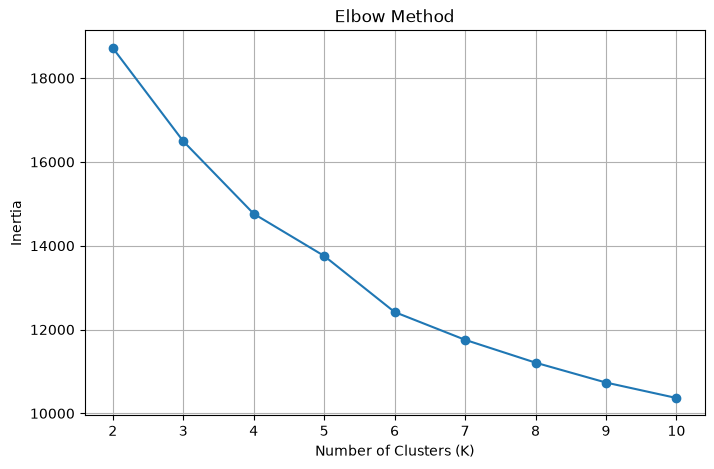

In [79]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [80]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.1470
K = 3: Silhouette Score = 0.1453
K = 4: Silhouette Score = 0.1626
K = 5: Silhouette Score = 0.1509
K = 6: Silhouette Score = 0.1612
K = 7: Silhouette Score = 0.1559
K = 8: Silhouette Score = 0.1661
K = 9: Silhouette Score = 0.1639
K = 10: Silhouette Score = 0.1591


In [81]:
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)

buyer_features["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(buyer_features["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0    267
1     47
2    334
3    102
4    444
5    336
6    251
7    219
Name: count, dtype: int64


In [82]:
cluster_profile = buyer_features.groupby("cluster")[feature_columns].mean().round(2)

cluster_profile

,age,satisfaction_score,purchase_count,total_purchase_value,avg_purchase_value,avg_floor_area,investment_flag,loan_flag,office_share,apartment_share,corporate_flag
cluster,,,,,,,,,,,
0,54.73,3.21,3.57,1522893.36,430346.28,1402.78,0.30,0.36,0.35,0.65,0.00
1,64.30,3.47,7.40,2458260.65,335220.86,1109.84,0.34,0.32,0.13,0.87,0.02
2,58.84,2.87,3.58,1115628.61,312472.80,1032.61,0.31,0.00,0.34,0.66,0.00
3,48.25,3.05,3.61,1240325.73,345480.71,1145.10,0.34,0.42,0.15,0.85,1.00
4,55.26,3.16,3.54,1072969.59,303388.44,1011.84,0.00,0.35,0.00,1.00,0.00
5,58.30,2.85,3.54,1479222.27,421153.84,1387.75,0.18,0.33,0.00,1.00,0.00
6,55.80,3.04,3.46,1105239.57,319609.57,1063.83,1.00,0.38,0.00,1.00,0.00
7,56.16,2.94,3.70,1135318.22,308141.40,1022.83,0.32,1.00,0.32,0.68,0.00


In [83]:
cluster_profile = buyer_features.groupby("cluster")[feature_columns].mean().round(2)

cluster_profile

,age,satisfaction_score,purchase_count,total_purchase_value,avg_purchase_value,avg_floor_area,investment_flag,loan_flag,office_share,apartment_share,corporate_flag
cluster,,,,,,,,,,,
0,54.73,3.21,3.57,1522893.36,430346.28,1402.78,0.30,0.36,0.35,0.65,0.00
1,64.30,3.47,7.40,2458260.65,335220.86,1109.84,0.34,0.32,0.13,0.87,0.02
2,58.84,2.87,3.58,1115628.61,312472.80,1032.61,0.31,0.00,0.34,0.66,0.00
3,48.25,3.05,3.61,1240325.73,345480.71,1145.10,0.34,0.42,0.15,0.85,1.00
4,55.26,3.16,3.54,1072969.59,303388.44,1011.84,0.00,0.35,0.00,1.00,0.00
5,58.30,2.85,3.54,1479222.27,421153.84,1387.75,0.18,0.33,0.00,1.00,0.00
6,55.80,3.04,3.46,1105239.57,319609.57,1063.83,1.00,0.38,0.00,1.00,0.00
7,56.16,2.94,3.70,1135318.22,308141.40,1022.83,0.32,1.00,0.32,0.68,0.00


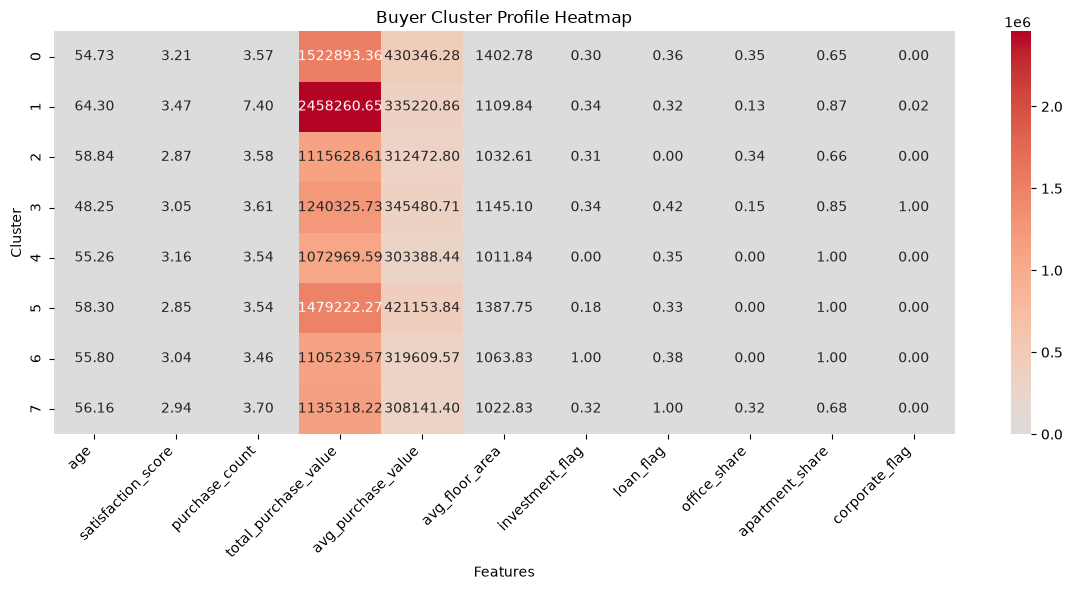

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Buyer Cluster Profile Heatmap")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


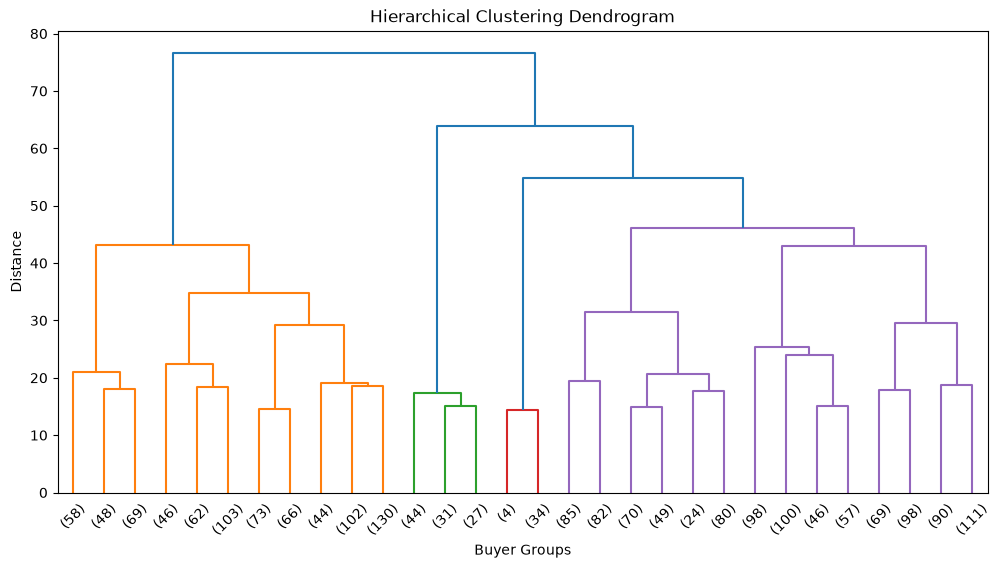

In [85]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Buyer Groups")
plt.ylabel("Distance")
plt.show()

In [86]:
investment_profile = buyer_features.groupby("investment_flag").agg(
    buyers=("client_id", "count"),
    avg_age=("age", "mean"),
    avg_purchases=("purchase_count", "mean"),
    avg_total_value=("total_purchase_value", "mean"),
    avg_purchase_value=("avg_purchase_value", "mean"),
    avg_floor_area=("avg_floor_area", "mean"),
    avg_loan_rate=("loan_flag", "mean"),
    avg_office_share=("office_share", "mean")
).round(2)

investment_profile


,buyers,avg_age,avg_purchases,avg_total_value,avg_purchase_value,avg_floor_area,avg_loan_rate,avg_office_share
investment_flag,,,,,,,,
0,1385,56.67,3.65,1263587.55,348086.94,1151.92,0.36,0.15
1,615,55.53,3.65,1253141.79,344844.71,1137.48,0.38,0.16


In [87]:
cluster_investment = pd.crosstab(
    buyer_features["cluster"],
    buyer_features["investment_flag"],
    normalize="index"
).round(2)

cluster_investment.columns = ["Non_Investment", "Investment"]

cluster_investment

,Non_Investment,Investment
cluster,,
0,0.70,0.30
1,0.66,0.34
2,0.69,0.31
3,0.66,0.34
4,1.00,0.00
5,0.82,0.18
6,0.00,1.00
7,0.68,0.32


In [88]:
final_cluster_profile = buyer_features.groupby("cluster").agg(
    buyers=("client_id", "count"),
    avg_age=("age", "mean"),
    avg_purchases=("purchase_count", "mean"),
    avg_total_value=("total_purchase_value", "mean"),
    avg_purchase_value=("avg_purchase_value", "mean"),
    avg_floor_area=("avg_floor_area", "mean"),
    investment_rate=("investment_flag", "mean"),
    loan_rate=("loan_flag", "mean"),
    office_share=("office_share", "mean"),
    apartment_share=("apartment_share", "mean"),
    corporate_rate=("corporate_flag", "mean")
).round(2)

final_cluster_profile["investment_rate"] = (
    final_cluster_profile["investment_rate"] * 100
).round(1)

final_cluster_profile["loan_rate"] = (
    final_cluster_profile["loan_rate"] * 100
).round(1)

final_cluster_profile["office_share"] = (
    final_cluster_profile["office_share"] * 100
).round(1)

final_cluster_profile["apartment_share"] = (
    final_cluster_profile["apartment_share"] * 100
).round(1)

final_cluster_profile["corporate_rate"] = (
    final_cluster_profile["corporate_rate"] * 100
).round(1)

final_cluster_profile

,buyers,avg_age,avg_purchases,avg_total_value,avg_purchase_value,avg_floor_area,investment_rate,loan_rate,office_share,apartment_share,corporate_rate
cluster,,,,,,,,,,,
0,267,54.73,3.57,1522893.36,430346.28,1402.78,30.0,36.0,35.0,65.0,0.0
1,47,64.30,7.40,2458260.65,335220.86,1109.84,34.0,32.0,13.0,87.0,2.0
2,334,58.84,3.58,1115628.61,312472.80,1032.61,31.0,0.0,34.0,66.0,0.0
3,102,48.25,3.61,1240325.73,345480.71,1145.10,34.0,42.0,15.0,85.0,100.0
4,444,55.26,3.54,1072969.59,303388.44,1011.84,0.0,35.0,0.0,100.0,0.0
5,336,58.30,3.54,1479222.27,421153.84,1387.75,18.0,33.0,0.0,100.0,0.0
6,251,55.80,3.46,1105239.57,319609.57,1063.83,100.0,38.0,0.0,100.0,0.0
7,219,56.16,3.70,1135318.22,308141.40,1022.83,32.0,100.0,32.0,68.0,0.0


In [89]:
buyer_features.to_csv(
    "../data/buyer_segments.csv",
    index=False
)

final_cluster_profile.to_csv(
    "../data/cluster_profile.csv"
)

print("Saved:")
print("../data/buyer_segments.csv")
print("../data/cluster_profile.csv")

Saved:
../data/buyer_segments.csv
../data/cluster_profile.csv
